# Exploration approfondie de la base d'apprentissage

In [110]:
import pandas as pd
import sys
import os
import warnings

warnings.filterwarnings("ignore")

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 

from eda import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [111]:
# Configuration
FILE_PATH = "../data_finale/base_apprentissage_maj.csv"
TARGET    = "market_value_in_eur"
dossier_sauvegarde = "../outputs/eda"

In [112]:
print("Chargement du dataset")

df_base = pd.read_csv(FILE_PATH)

# Taille du dataset
print(f"Taille du dataset : {df_base.shape[0]:,} lignes × {df_base.shape[1]} colonnes")

Chargement du dataset
Taille du dataset : 15,466 lignes × 262 colonnes


In [113]:
print("Types des variables")

analyser_types_et_stats(df_base)

Types des variables
Analyse des types de variables
Variables numériques   : 258
Variables catégorielles: 4

Statistiques descriptives (variables numériques)
                                   count          mean           std       min           25%           50%           75%           max
age                              15466.0  2.600511e+01  4.550884e+00     14.00  2.300000e+01  2.600000e+01  2.900000e+01  4.400000e+01
born                             15466.0  1.996386e+03  4.752437e+00   1977.00  1.993000e+03  1.997000e+03  2.000000e+03  2.008000e+03
Playing Time_MP                  15466.0  2.040211e+01  1.122348e+01      1.00  1.100000e+01  2.300000e+01  3.000000e+01  6.600000e+01
Playing Time_Starts              15466.0  1.476988e+01  1.124994e+01      0.00  4.000000e+00  1.400000e+01  2.400000e+01  5.600000e+01
Playing Time_Min                 15466.0  1.324850e+03  9.606923e+02      1.00  4.410000e+02  1.252000e+03  2.103750e+03  4.967000e+03
Playing Time_90s                 

In [114]:
# Conversion de l'âge en numérique
df_base["age"] = pd.to_numeric(df_base["age"], errors="coerce")

# Saison lisible
season_map = {2021:"2020/21", 2122:"2021/22", 2223:"2022/23",
              2324:"2023/24", 2425:"2024/25", 2526:"2025/26"}
df_base["season_label"] = df_base["season_year"].map(season_map).fillna(df_base["season_year"].astype(str))

TARGET_M = TARGET  # en euros ; on divisera par 1e6 pour afficher en millions

Analyse des valeurs manquantes
                        nb_missing    pct
contrat_jours_restants        3895  25.18
market_value_in_eur           2637  17.05
nation                           4   0.03

Graphique sauvegardé sous : ..\outputs\eda\valeurs_manquantes.png


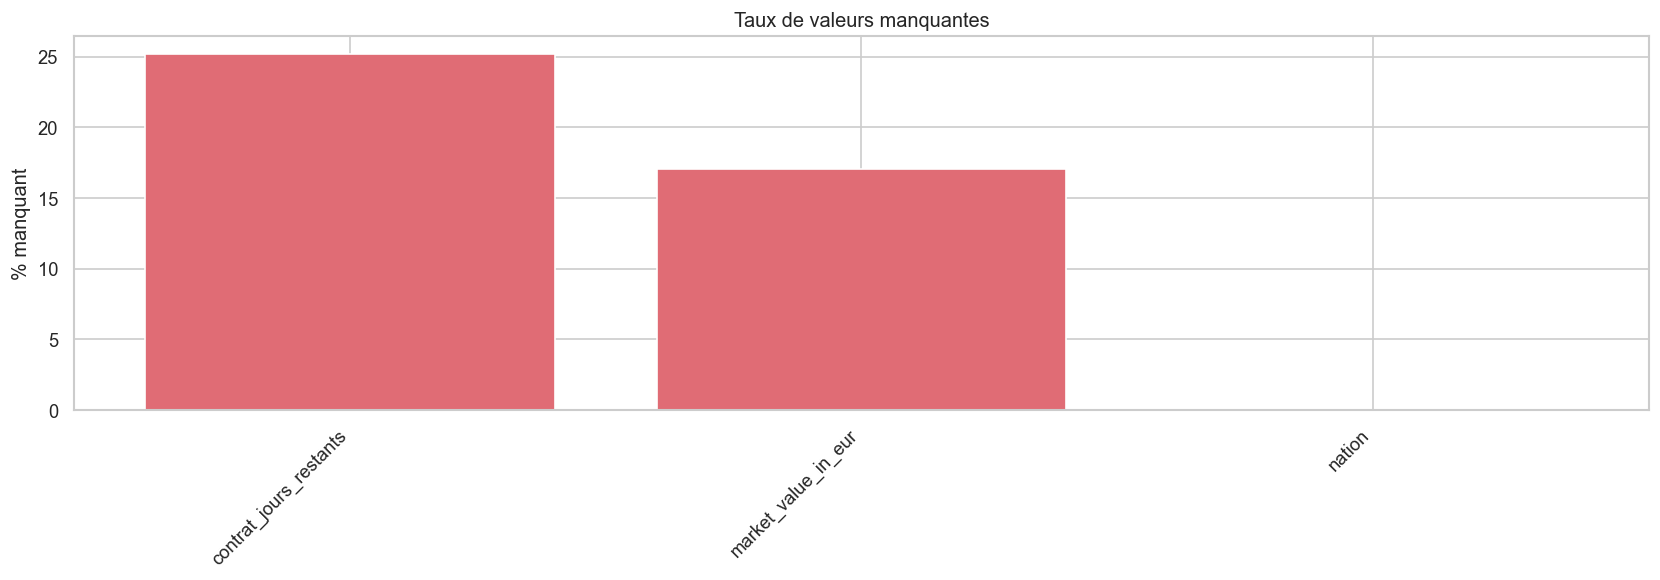

In [115]:
analyser_valeurs_manquantes(df_base, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la variable cible : market_value_in_eur
count         12,829
mean      12,027,050
std       17,094,496
min           50,000
25%        2,000,000
50%        5,000,000
75%       15,000,000
max      200,000,000
Name: market_value_in_eur, dtype: str

Skewness : 3.37
Kurtosis : 17.31

Graphique sauvegardé sous : ..\outputs\eda\distribution_market_value_in_eur.png


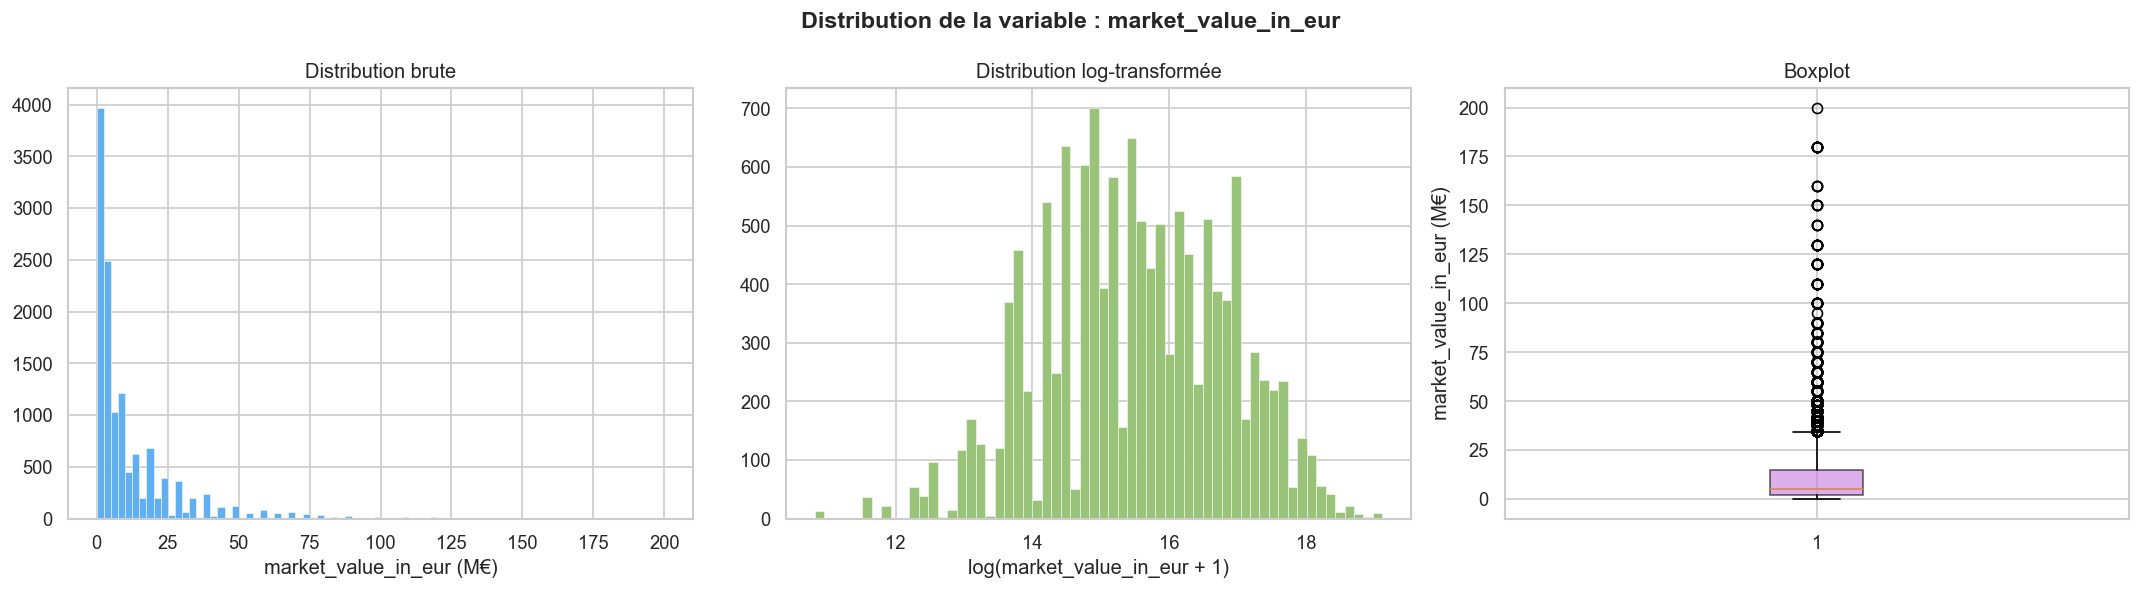

In [116]:
analyser_variable_cible(df_base, target_col=TARGET, dossier_sauvegarde=dossier_sauvegarde)

Distributions des variables numériques clés

Graphique sauvegardé sous : ..\outputs\eda\distributions_variables_numeriques_cles.png


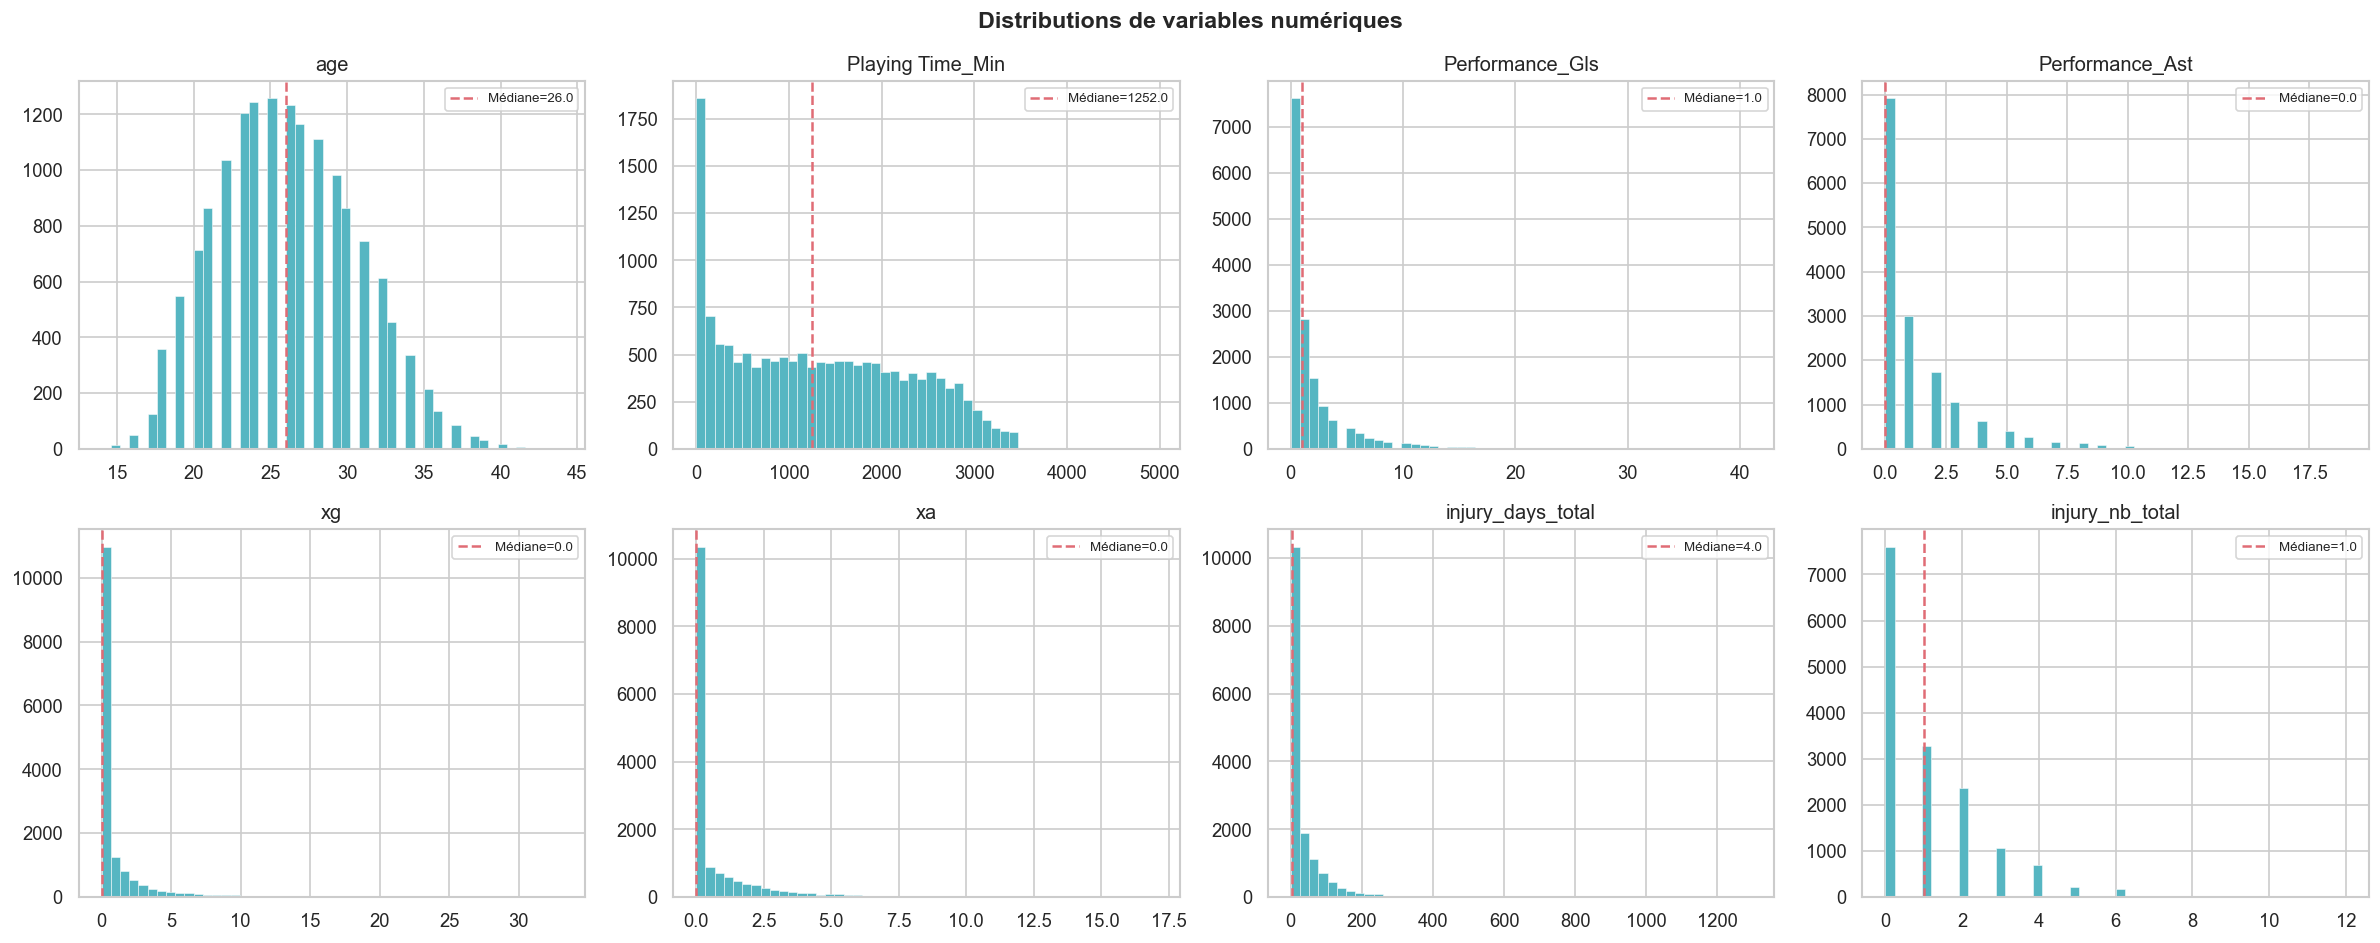

In [117]:
analyser_distributions_numeriques(df_base, cols_a_analyser=None, dossier_sauvegarde=dossier_sauvegarde)

Analyse des variables catégorielles

players_top_nations.png sauvegardé


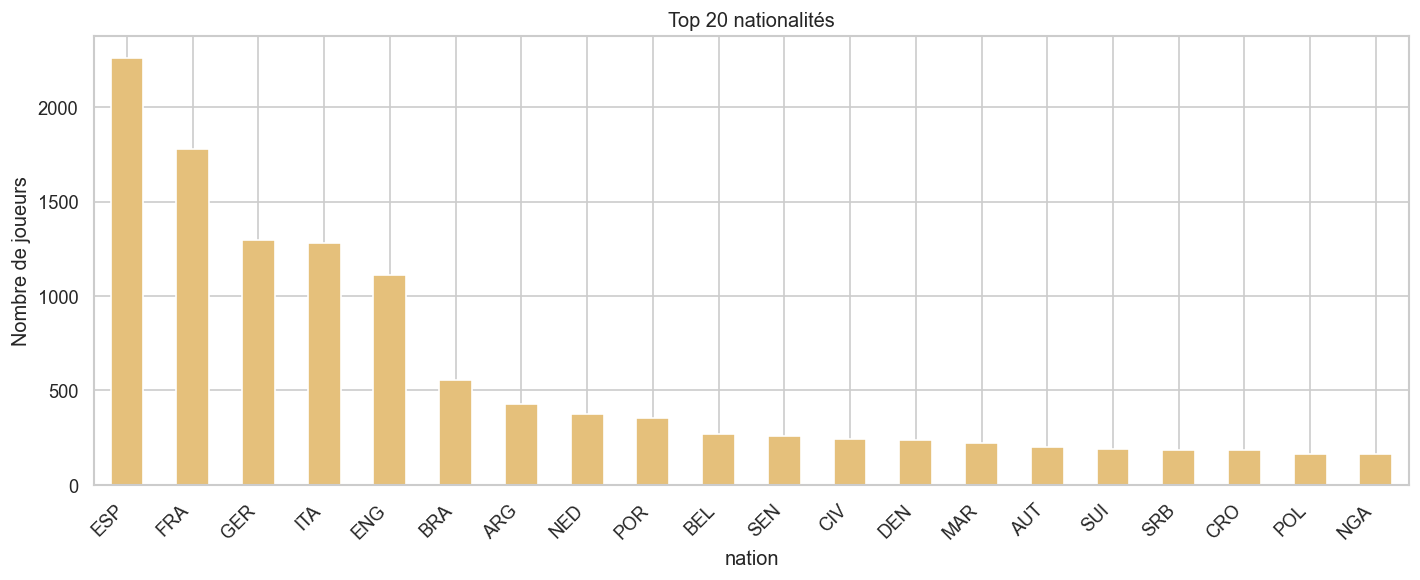

In [118]:
analyser_variables_categorielles(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

In [119]:
analyser_outliers(df_base)

Détection des outliers
         variable  outliers_IQR  pct_IQR  outliers_Zscore  total
              age            61      0.4               29  15466
 Playing Time_Min             2      0.0                3  15466
  Performance_Gls          1517      9.8              359  15466
  Performance_Ast           740      4.8              331  15466
               xg          2108     13.6              385  15466
               xa          1959     12.7              414  15466
injury_days_total          1434      9.3              318  15466
  injury_nb_total           245      1.6              245  15466


Analyse des relations avec la variable cible : market_value_in_eur

Graphique sauvegardé sous : ..\outputs\eda\relations_market_value_in_eur.png


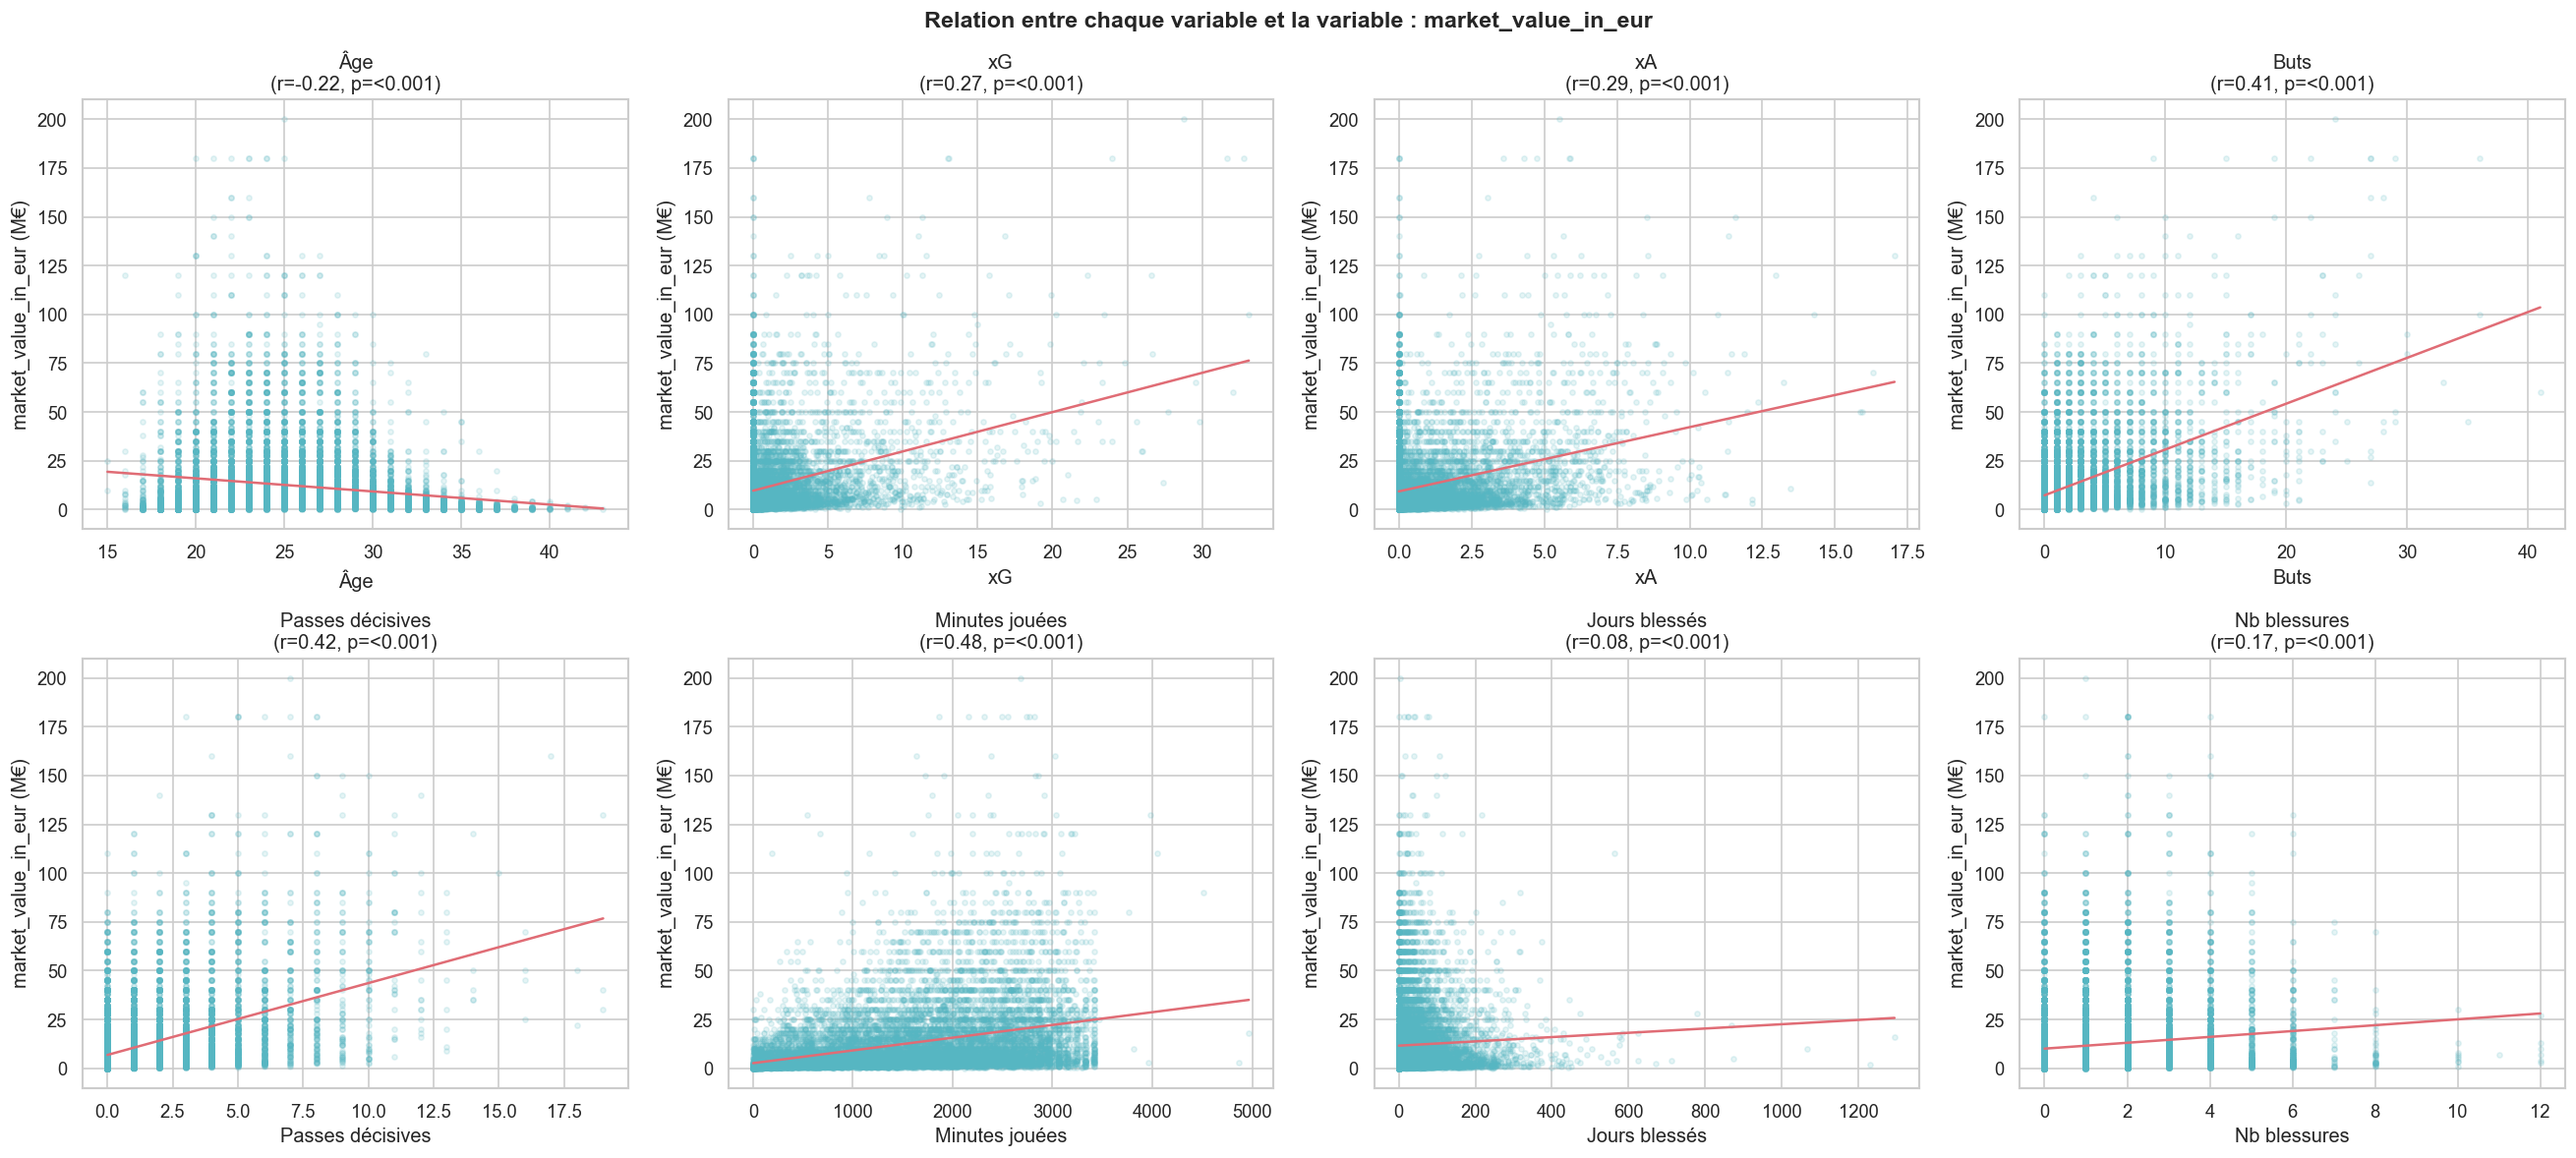

In [120]:
analyser_relations_cible(df_base, TARGET, variables_regresseurs=None, dossier_sauvegarde=dossier_sauvegarde)

Analyse des corrélations (cible : market_value_in_eur)

Corrélation linéaire avec la cible (variables clés)
                     market_value_in_eur
market_value_in_eur             1.000000
Performance_Gls                 0.466844
Performance_Ast                 0.446722
Playing Time_Min                0.356719
xg                              0.318616
xa                              0.310252
injury_nb_total                 0.130651
injury_days_total               0.042188
age                            -0.175933

matrice_correlation.png sauvegardé sous : ..\outputs\eda\matrice_correlation.png


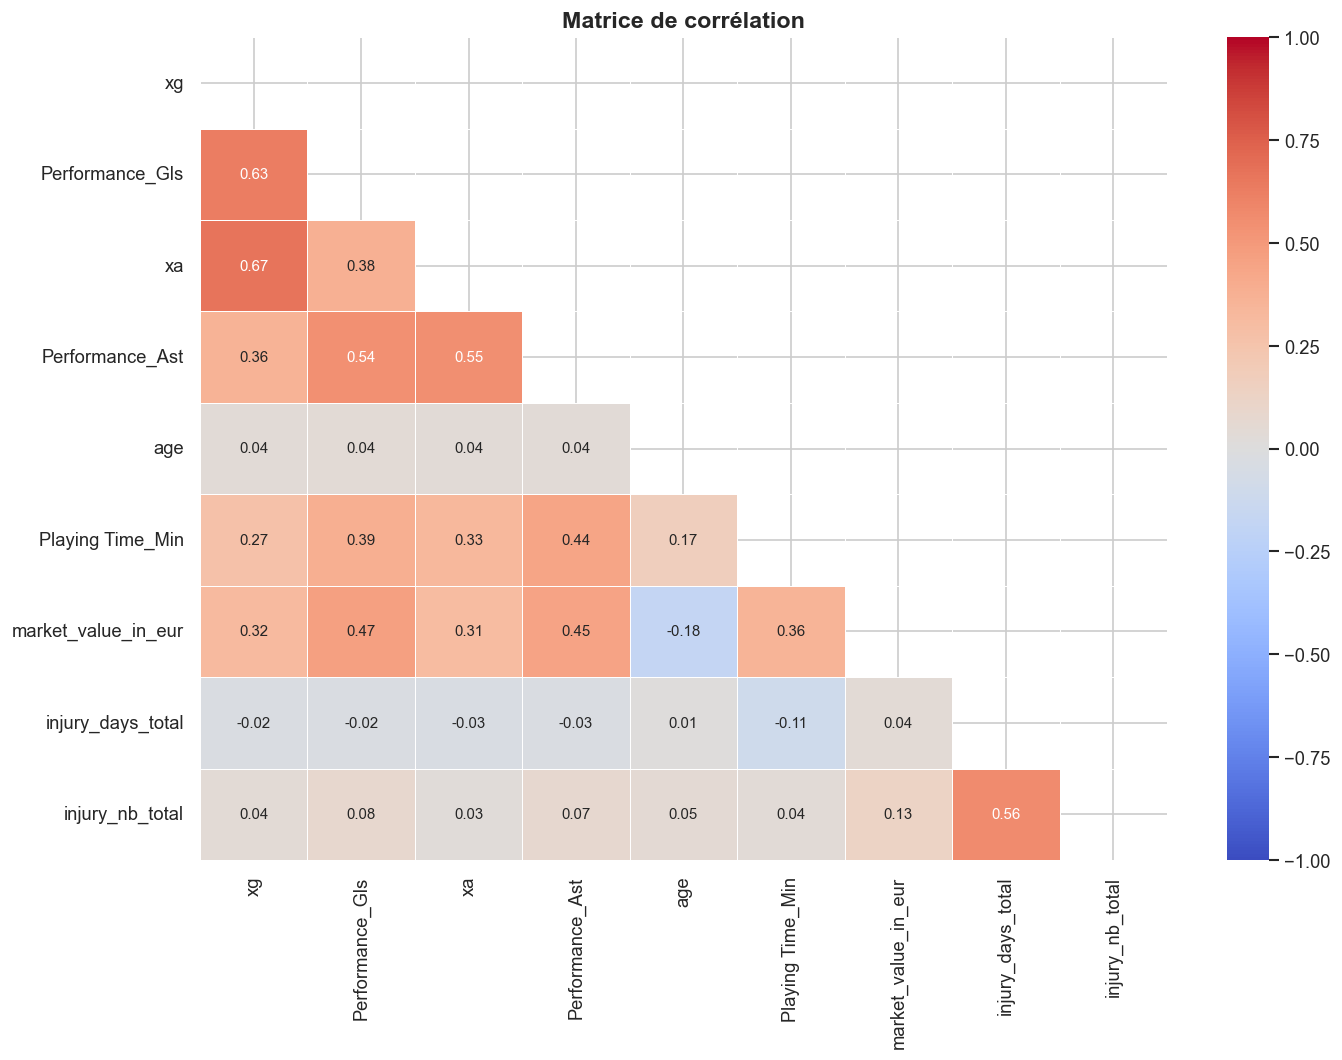


Top 20 des corrélations absolues avec market_value_in_eur (Toutes variables numériques)
market_value_in_eur_nor    1.000000
Team Success_onG           0.552116
Team Success_onG_nor       0.552116
Performance_G+A            0.519425
Performance_G+A_nor        0.519425
Team Success_+/-_nor       0.519209
Team Success_+/-           0.519209
Standard_Sh                0.483420
Standard_Sh_nor            0.483420
Standard_SoT_nor           0.479340
Standard_SoT               0.479340
Performance_G-PK_nor       0.473369
Performance_G-PK           0.473369
Standard_Gls               0.466844
Performance_Gls            0.466844
Performance_Gls_nor        0.466844
Standard_Gls_nor           0.466844
Performance_Ast_nor        0.446722
Performance_Ast            0.446722
xg_chain                   0.379609


In [121]:
analyser_correlations(df_base, TARGET, cols_cles=None, dossier_sauvegarde=dossier_sauvegarde)

## Segmentation par poste

In [122]:
df_base

,player,team,nation,age,born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,Playing Time_90s,Performance_Gls,...,injury_musculaire_nor,injury_genou_nor,injury_cheville_pied_nor,injury_mollet_tibia_nor,injury_dos_bassin_nor,injury_trauma_severe_nor,injury_medical_repos_nor,injury_minor_unknown_nor,contrat_jours_restants_nor,season_label
0,Aaron Ciammaglichella,Torino,ITA,24,2000,1,0,1,0.0,0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.285742,2024
1,Aaron Connolly,Brighton,IRL,20,2000,17,9,791,8.8,2,...,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.214356,2020
2,Aaron Connolly,Brighton,IRL,21,2000,4,1,156,1.7,0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.285742,2020/21
3,Aaron Cresswell,West Ham United,ENG,31,1989,36,36,3170,35.2,0,...,0.333333,0.0,0.5,0.0,0.0,0.0,0.0,0.000000,0.357129,2020
4,Aaron Cresswell,West Ham United,ENG,32,1989,31,31,2726,30.3,2,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.285742,2020/21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15461,Šime Vrsaljko,Atlético Madrid,CRO,28,1992,9,6,519,5.8,0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.285742,2020
15462,Šime Vrsaljko,Atlético Madrid,CRO,29,1992,21,10,914,10.2,1,...,0.000000,0.0,0.0,0.0,0.0,0.5,0.0,0.333333,0.285742,2020/21
15463,Ștefan Radu,Lazio,ROU,34,1986,31,30,2458,27.3,0,...,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.285742,2020
15464,Ștefan Radu,Lazio,ROU,35,1986,10,6,556,6.2,0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.5,0.333333,0.285742,2020/21


Analyse du profil médian par poste

Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_profil_poste.png


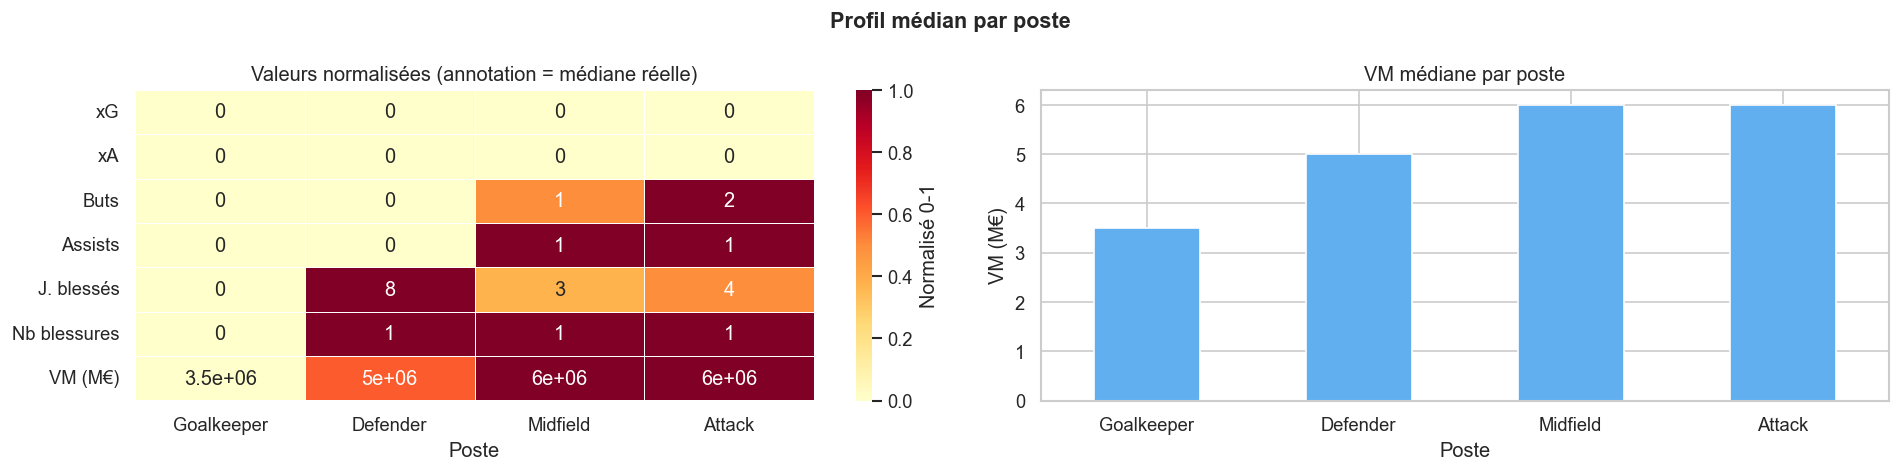

In [123]:
analyser_profil_par_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse des corrélations spécifiques par poste

Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_corr_poste.png


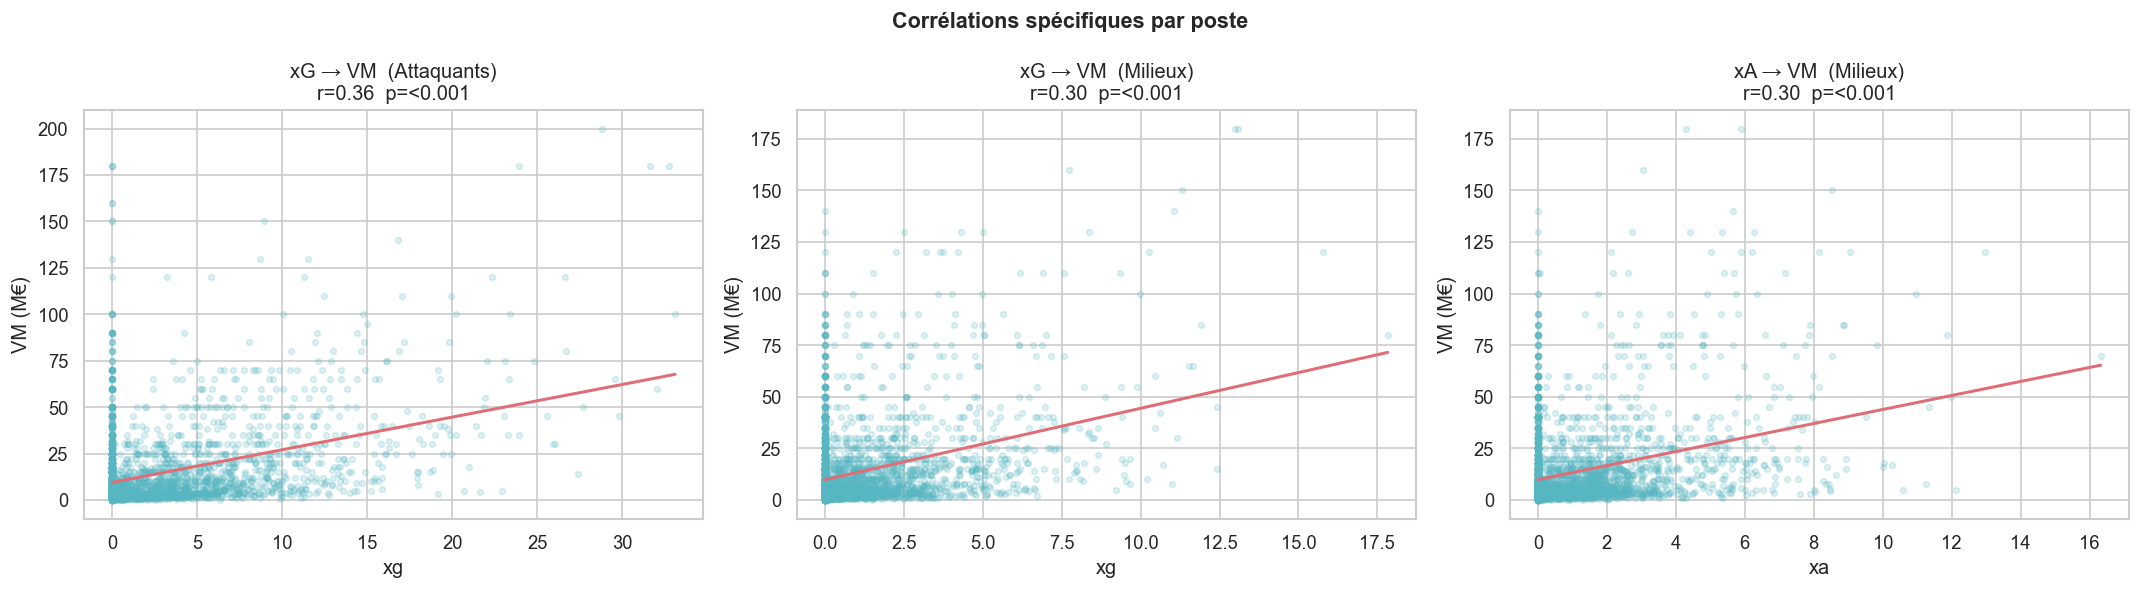

In [124]:
analyser_correlations_specifiques_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse de la distribution des âges par poste
Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_age_par_poste.png


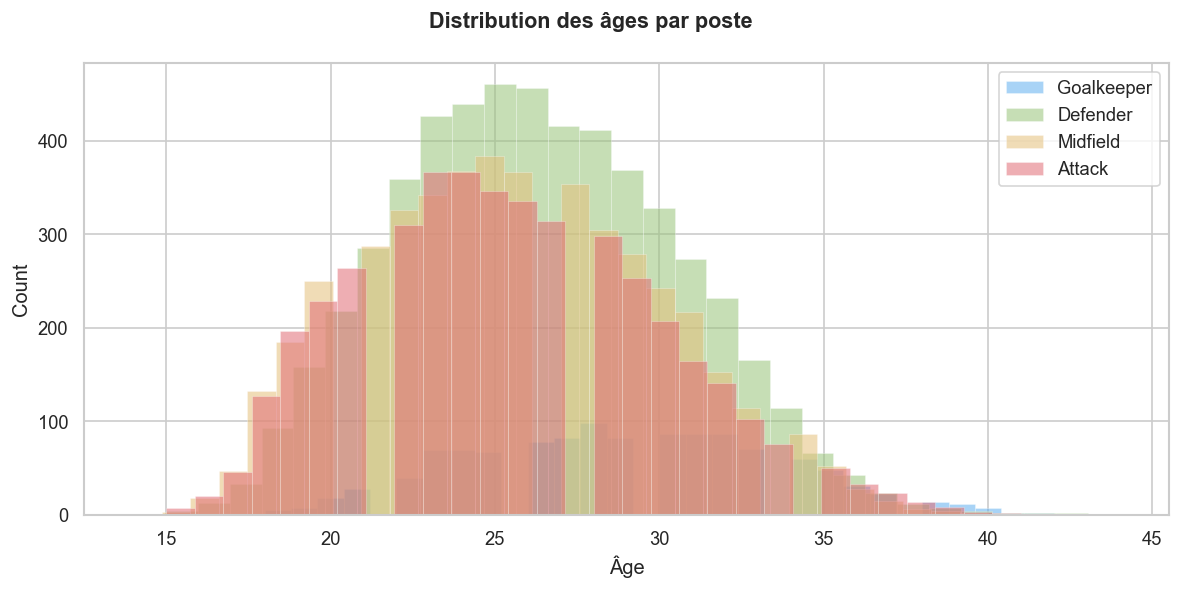


Âge médian par poste
position
Goalkeeper    29.0
Defender      26.0
Midfield      25.0
Attack        25.0


In [125]:
analyser_ages_par_poste(df_base, dossier_sauvegarde=dossier_sauvegarde, liste_couleurs=None)

Feature engineering exploratoire

Graphique sauvegardé sous : ..\outputs\eda\feature_engineering.png


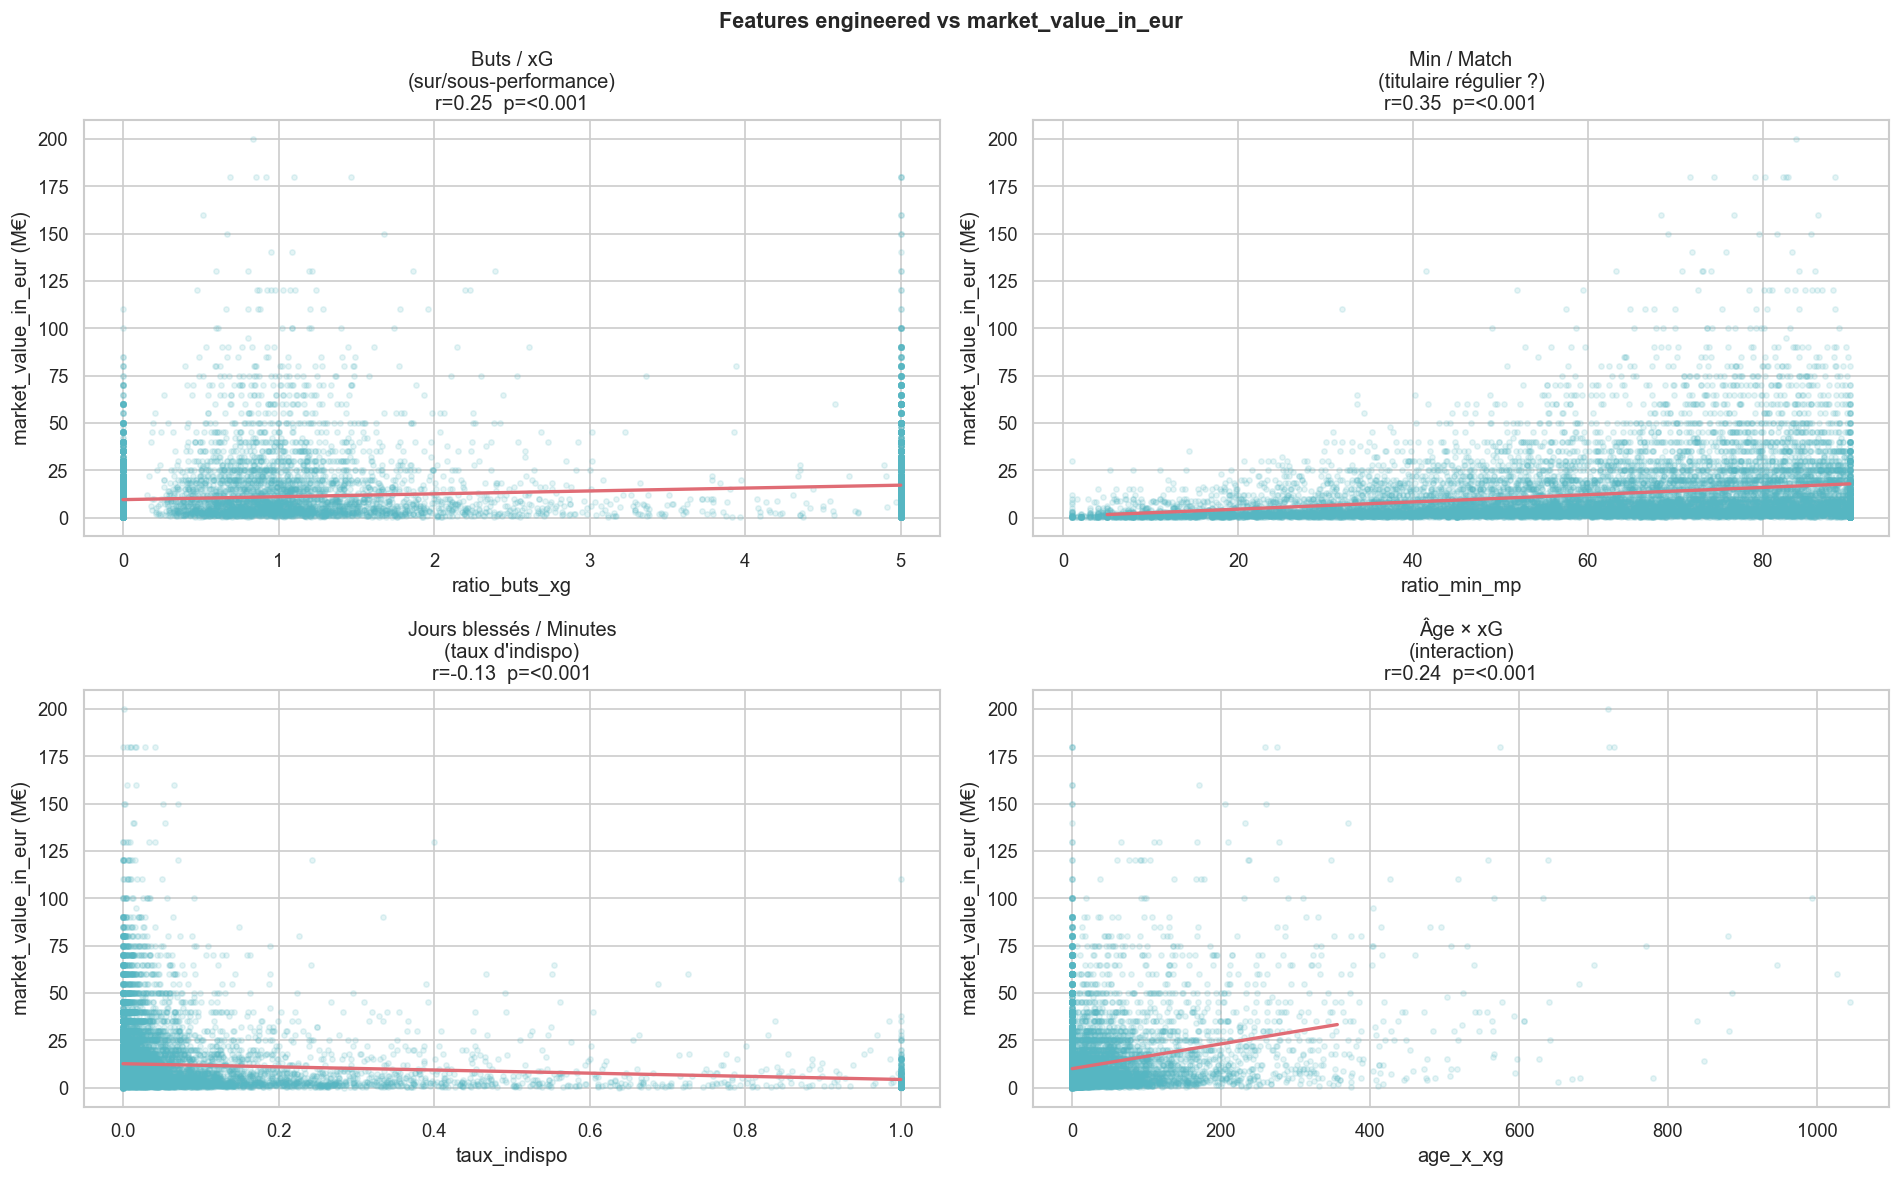


Corrélations (Pearson sur log market_value_in_eur) — features engineered :
  ratio_buts_xg        r=+0.253  p=<0.001
  ratio_min_mp         r=+0.347  p=<0.001
  taux_indispo         r=-0.129  p=<0.001
  age_x_xg             r=+0.245  p=<0.001


In [126]:
analyser_feature_engineering(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

In [127]:
analyser_heatmap_league_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

Analyse croisée : VM médiane par championnat et par poste
Annulé : La colonne 'league' est absente du DataFrame.


In [128]:
analyser_distribution_violin_league(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse de la distribution par championnat
Annulé : La colonne 'league' est absente du DataFrame.


Analyse des outliers et profils Spécifiques (cible : market_value_in_eur)

Joueurs avec market_value_in_eur ≥ 100M€ : 69 observations

Top 20 des joueurs les plus chers
           player position season_label  age  market_value_in_eur        xg  Performance_Gls  injury_days_total
   Erling Haaland   Attack         2025   25                200.0 28.795336               24                4.0
   Erling Haaland   Attack         2023   23                180.0 31.653997               27               73.0
   Erling Haaland   Attack         2022   22                180.0 32.761400               36               24.0
   Erling Haaland   Attack         2024   24                180.0 23.954593               22               42.0
  Jude Bellingham Midfield         2023   20                180.0 12.974516               19               40.0
  Vinicius Júnior   Attack         2023   23                180.0  0.000000               15               77.0
    Kylian Mbappé   Attack         2023   25   

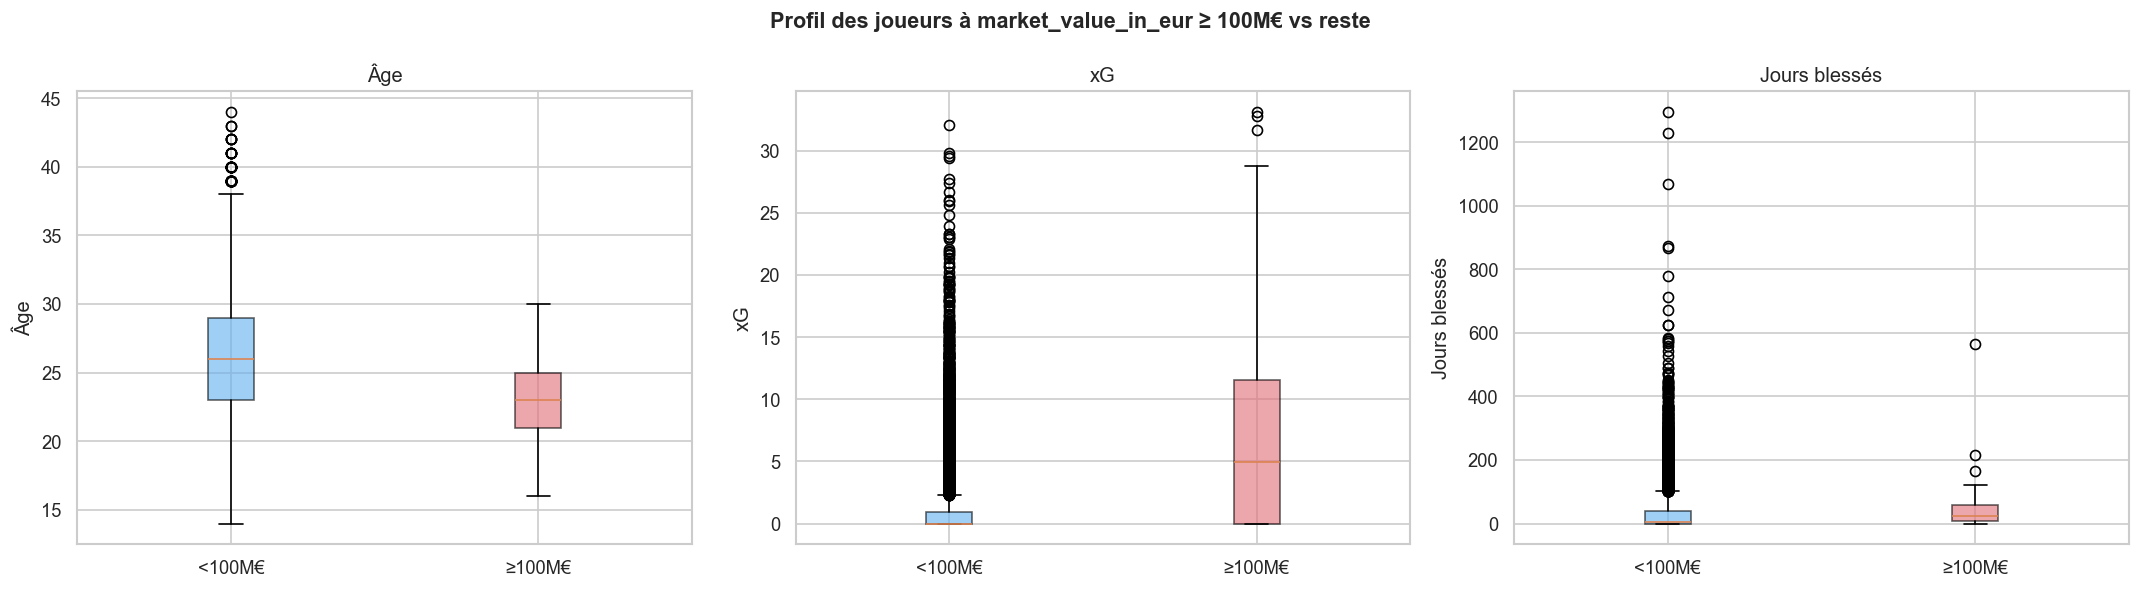

In [129]:
analyser_profil_outliers(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse des résidus de régression (xG → log(market_value_in_eur))

Régression xG → log(market_value_in_eur)  |  R²=0.075
  Sur-évalués  (résidu > +2.5σ) : 12
  Sous-évalués (résidu < -2.5σ) : 76

Graphique sauvegardé sous : ..\outputs\eda\outliers_residus.png


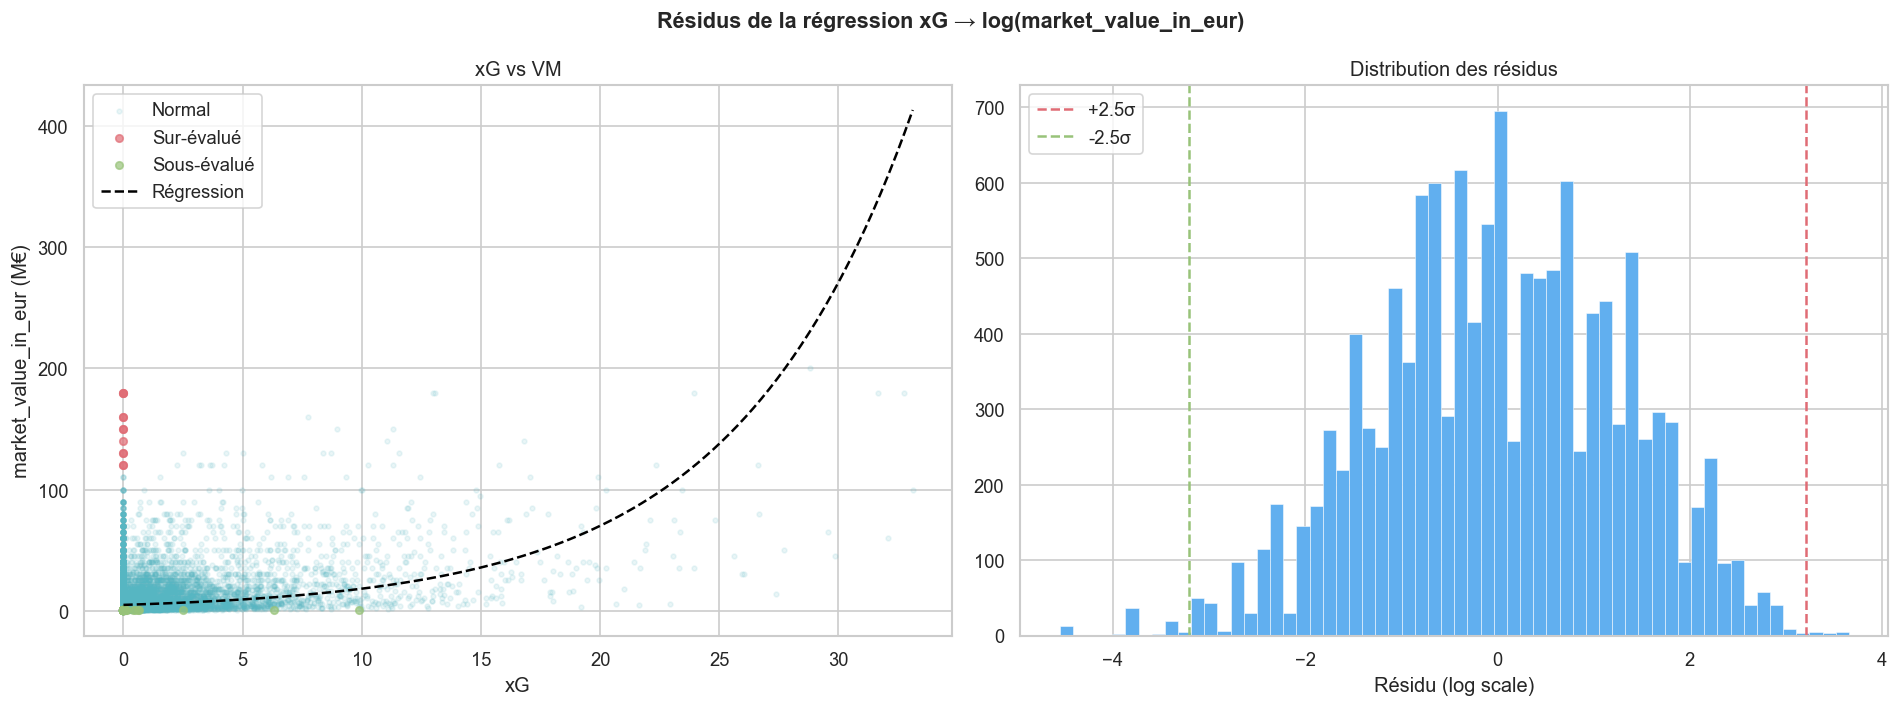

In [130]:
df_res = analyser_residus_regression(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

In [131]:
afficher_top_anomalies_valeur(df_res, TARGET)

Top joueurs atypiques (Régression vs market_value_in_eur)

Top 10 joueurs les plus SUR-évalués vs xG :
         player position  age  xg  market_value_in_eur  residual
Vinicius Júnior   Attack   23 0.0                180.0  3.652462
  Kylian Mbappé   Attack   24 0.0                180.0  3.652462
  Kylian Mbappé   Attack   25 0.0                180.0  3.652462
  Kylian Mbappé   Attack   23 0.0                160.0  3.534679
  Kylian Mbappé   Attack   22 0.0                160.0  3.534679
Vinicius Júnior   Attack   22 0.0                150.0  3.470140
 Erling Haaland   Attack   21 0.0                150.0  3.470140
  Florian Wirtz Midfield   21 0.0                140.0  3.401147
  Florian Wirtz Midfield   20 0.0                130.0  3.327039
 Erling Haaland   Attack   20 0.0                130.0  3.327039

Top 10 joueurs les plus SOUS-évalués vs xG :
            player   position  age       xg  market_value_in_eur  residual
     Niama Sissoko     Attack   19 0.138512                  

In [132]:
verifier_coherence_jours_blessures(df_base)

Contrôle de cohérence : jours de blessures

Cohérence injury_days_total vs somme des composantes (15466/15466 lignes analysées) :
  Cohérents (diff = 0)           : 14,874
  Diff ≤ 1 jour                  : 14,874
  Diff > 1 jour (anomalie)       : 592
  Diff max                       : 1229 jours

Des incohérences ont été détectées. Cela peut provenir de blessures
 qui se chevauchent dans le temps ou de catégories non répertoriées ici.


Analyse de l'évolution temporelle par Saison (cible : market_value_in_eur)

Évolution VM par saison :
              Médiane (M€)  Moyenne (M€)  Nb joueurs
season_label                                        
2020                   5.0     10.589601        2505
2020/21                5.0     10.671248        2419
2022                   5.0     11.328877        2476
2023                   5.0     12.144944        2413
2024                   6.5     13.440425        1731
2025                   9.0     16.601479        1285

Graphique sauvegardé sous : ..\outputs\eda\evolution_temporelle.png


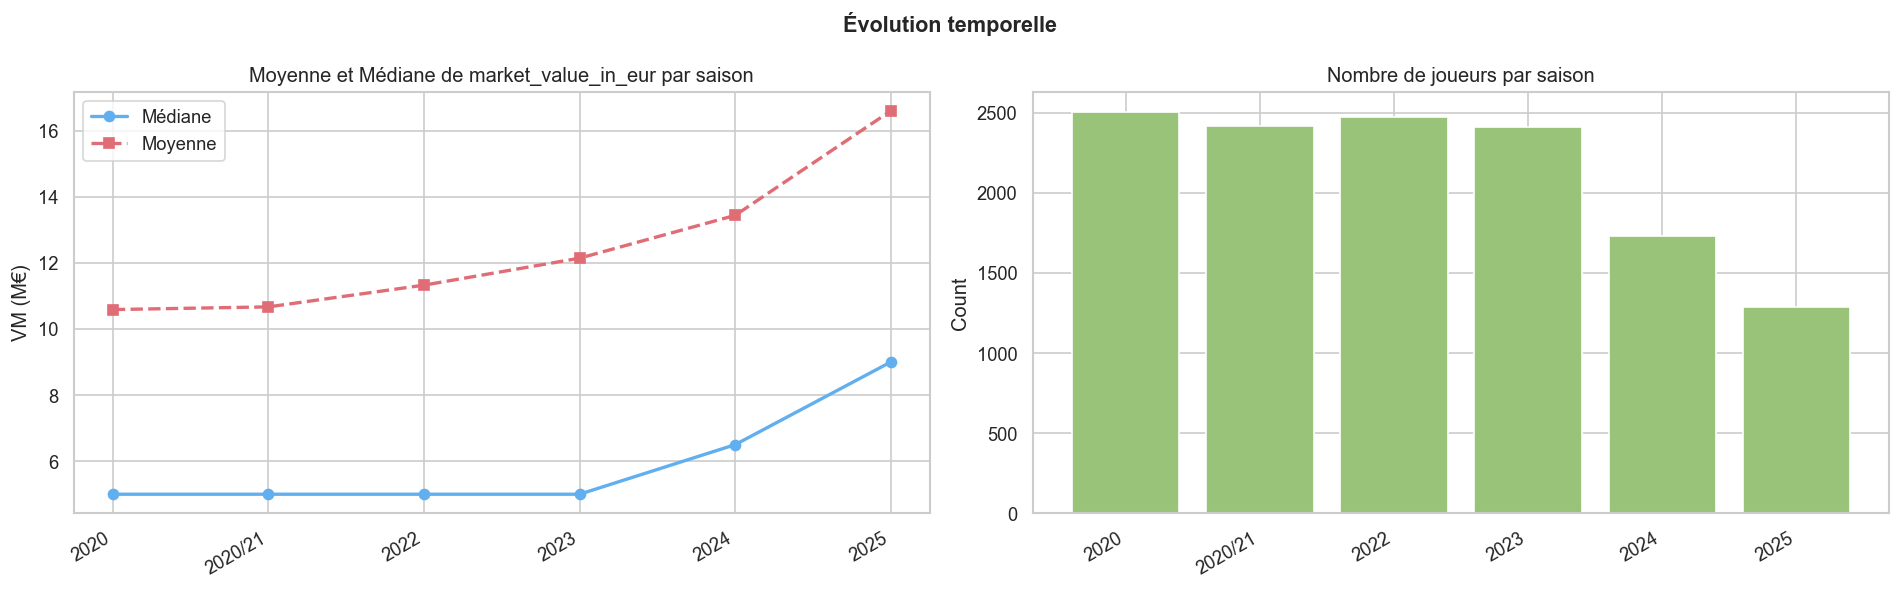

,Médiane (M€),Moyenne (M€),Nb joueurs
season_label,,,
2020,5.0,10.589601,2505
2020/21,5.0,10.671248,2419
2022,5.0,11.328877,2476
2023,5.0,12.144944,2413
2024,6.5,13.440425,1731
2025,9.0,16.601479,1285


In [133]:
analyser_evolution_temporelle_saison(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

# DERNIERES ANALYSES EDA

In [134]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Charger la base si ce n'est pas déjà fait dans votre session
df = pd.read_csv("../data_finale/base_apprentissage.csv")

Analyse lancée sur 17122 observations (Postes nettoyés : <ArrowStringArray>
['MF', 'FW', 'GK', 'DF']
Length: 4, dtype: str).


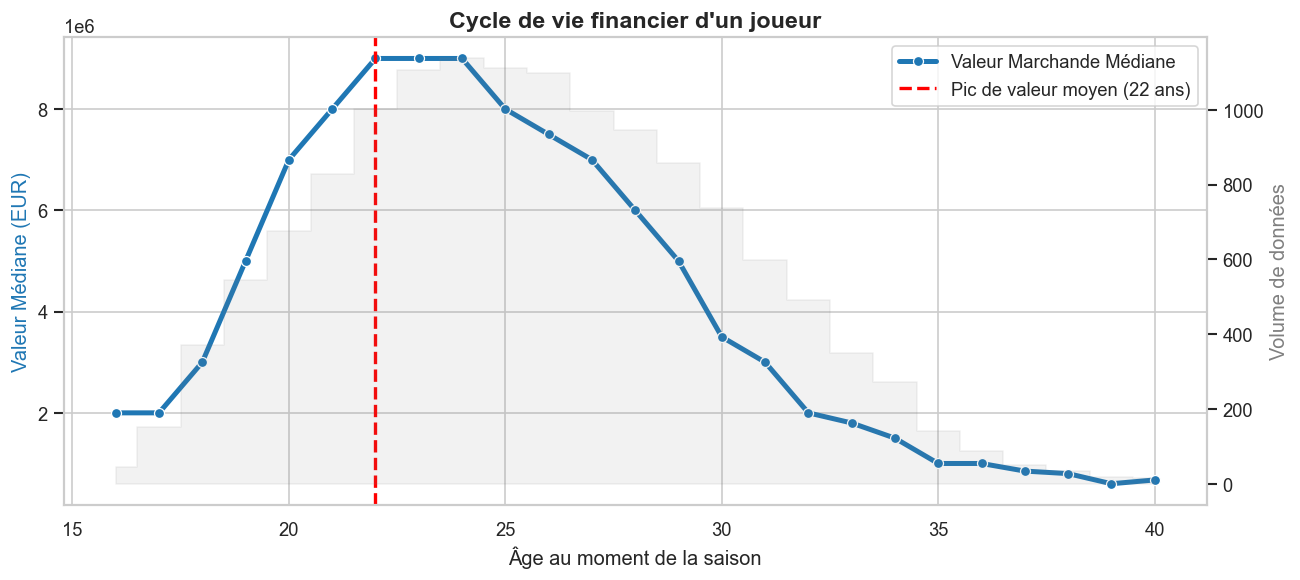

In [135]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuration et nettoyage
sns.set_theme(style="whitegrid")

# Nettoyage du format de l'âge
df["age"] = df["age"].astype(str).str.split("-").str[0]
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# Sécurisation du poste
df["pos"] = df["pos"].astype(str).str.split(",").str[0]

# Dictionnaire de secours pour harmoniser la nomenclature si besoin
mapping_postes = {
    "FW": "FW",
    "MF": "MF",
    "DF": "DF",
    "GK": "GK",
    "Attaquant": "FW",
    "Milieu": "MF",
    "Défenseur": "DF",
    "Gardien": "GK",
}
df["pos"] = df["pos"].map(mapping_postes).fillna(df["pos"])

# On ne garde que les 4 catégories majeures valides
df = df[df["pos"].isin(["FW", "MF", "DF", "GK"])]

print(
    f"Analyse lancée sur {len(df)} observations (Postes nettoyés : {df['pos'].unique()})."
)


# Impact de l'âge sur la valeur marchande
age_profile = (
    df.groupby("age")["market_value_in_eur"]
    .agg(["median", "count"])
    .reset_index()
)
age_profile = age_profile[age_profile["count"] >= 10]

fig, ax1 = plt.subplots(figsize=(11, 5))

sns.lineplot(
    data=age_profile,
    x="age",
    y="median",
    marker="o",
    linewidth=3,
    color="#1f77b4",
    ax=ax1,
    label="Valeur Marchande Médiane",
)
ax1.set_ylabel("Valeur Médiane (EUR)", color="#1f77b4", fontsize=12)

ax2 = ax1.twinx()
ax2.fill_between(
    age_profile["age"],
    age_profile["count"],
    alpha=0.1,
    color="gray",
    step="mid",
    label="Nombre d'observations",
)
ax2.set_ylabel("Volume de données", color="gray", fontsize=12)
ax2.grid(False)

if not age_profile.empty:
    age_or = age_profile.loc[age_profile["median"].idxmax(), "age"]
    ax1.axvline(
        x=age_or,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Pic de valeur moyen ({int(age_or)} ans)",
    )

ax1.set_title(
    "Cycle de vie financier d'un joueur",
    fontsize=14,
    fontweight="bold",
)
ax1.set_xlabel("Âge au moment de la saison", fontsize=12)
ax1.legend(loc="upper right")
plt.tight_layout()
plt.show()

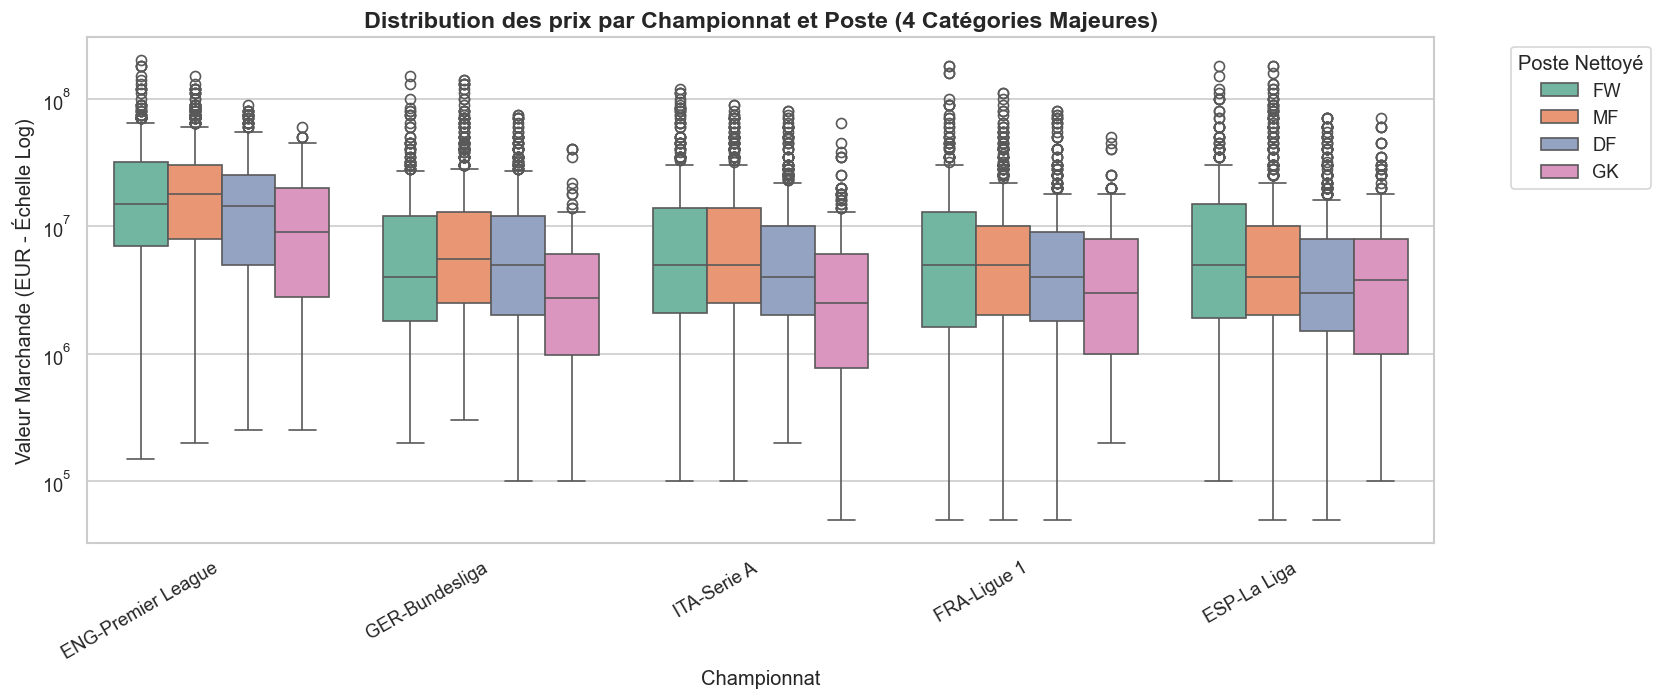

In [136]:
# Impact du poste et du championnat sur la valeur marchande
plt.figure(figsize=(14, 6))

# Tri des championnats par valeur marchande médiane décroissante
league_order = (
    df.groupby("league")["market_value_in_eur"]
    .median()
    .sort_values(ascending=False)
    .index
)

# Boxplot propre avec uniquement les 4 catégories
sns.boxplot(
    data=df,
    x="league",
    y="market_value_in_eur",
    hue="pos",
    hue_order=["FW", "MF", "DF", "GK"],  # Ordre fixe et propre des catégories
    order=league_order,
    palette="Set2",
)
plt.yscale("log")
plt.title(
    "Distribution des prix par Championnat et Poste (4 Catégories Majeures)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Championnat")
plt.ylabel("Valeur Marchande (EUR - Échelle Log)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Poste Nettoyé", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

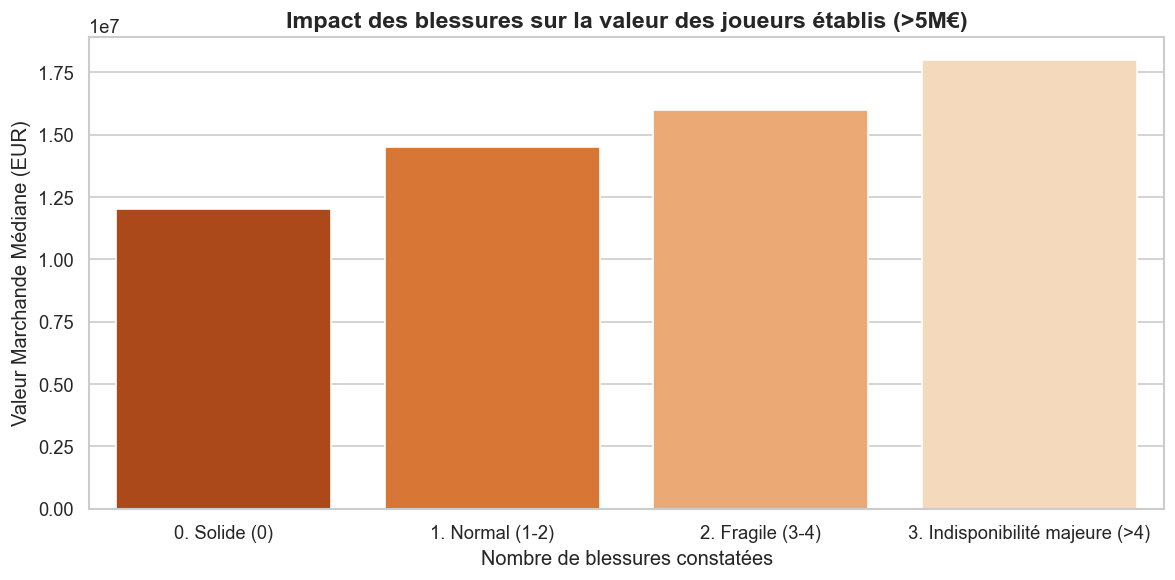

In [137]:
#Impact des blessures sur la valeur marchande (pour les joueurs établis >5M€)
df_majeurs = df[df["market_value_in_eur"] >= 5_000_000].copy()
df_majeurs["injury_nb_total"] = pd.to_numeric(
    df_majeurs["injury_nb_total"], errors="coerce"
).fillna(0)


def cat_blessures_indiv(nb):
    if nb == 0:
        return "0. Solide (0)"
    elif nb <= 2:
        return "1. Normal (1-2)"
    elif nb <= 4:
        return "2. Fragile (3-4)"
    else:
        return "3. Indisponibilité majeure (>4)"


df_majeurs["Blessures_Saison"] = df_majeurs["injury_nb_total"].apply(
    cat_blessures_indiv
)
categories_ordonnees = [
    cat
    for cat in [
        "0. Solide (0)",
        "1. Normal (1-2)",
        "2. Fragile (3-4)",
        "3. Indisponibilité majeure (>4)",
    ]
    if cat in df_majeurs["Blessures_Saison"].unique()
]

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_majeurs,
    x="Blessures_Saison",
    y="market_value_in_eur",
    order=categories_ordonnees,
    estimator=np.median,
    palette="Oranges_r",
    errorbar=None,
)
plt.title(
    "Impact des blessures sur la valeur des joueurs établis (>5M€)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Nombre de blessures constatées")
plt.ylabel("Valeur Marchande Médiane (EUR)")
plt.tight_layout()
plt.show()